# Deep Neural Network Mathematical Foundation
This documentation outlines the mathematical operations for an L-layer [feed forward neural network](https://en.wikipedia.org/wiki/Feedforward_neural_network) processing a batch of m examples. The architecture is defined by the number of units $a^{[l]}$ in each layer, where $l = 0$ represents the input layer and $l = L$ represents the output layer.

## 1. Forward Propagation
During forward propagation, the network computes the [linear combination](https://en.wikipedia.org/wiki/Linear_combination) of inputs and weights, followed by a non-linear [activation function](https://en.wikipedia.org/wiki/Activation_function). For any given layer $l$:

$$Z^{[l]} = W^{[l]}A^{[l-1]} + b^{[l]}$$

$$A^{[l]} = g^{[l]}(Z^{[l]})$$

**Hidden Layers** ($l = 1, 2, ..., L - 1$)

Regardless of the number of hidden layers or neurons, a common and effective choice for the hidden activation function $g^{[l]}$ is the Rectified Linear Unit (ReLU). It introduces non-linearity by outputting the input directly if it is positive, and zero otherwise:

$$A^{[l]} = \max(0, Z^{[l]})$$

**Output Layer** ($l = L$)

The activation function for the output unit $g^{[L]}$ depends entirely on the nature of the predictive modeling problem:

<center>

| Problem Type | Output Activation $g^{[L]}(Z)$ | Formula |
|:---:|:---:|:---:|
| Multiclass Classification | [Softmax](https://en.wikipedia.org/wiki/Softmax_function) | $\frac{e^{Z_i}}{\sum_{j} e^{Z_j}}$ |
| Binary Classification | [Sigmoid](https://en.wikipedia.org/wiki/Sigmoid_function) | $\frac{1}{1 + e^{-Z}}$ |
| Regression | Linear (Identity) | $Z$ |

</center>

## 2. The Chain Rule

It is necessary to establish the chain rule, which governs how parameters influence the final loss value. The chain rule allows us to compute the [derivative](https://en.wikipedia.org/wiki/Derivative) of a [composite function](https://en.wikipedia.org/wiki/Function_composition) by multiplying the derivatives of its constituent functions.

Let $x$ be a real number, and let $f$ and $g$ both be functions mapping from a real number to a real number. Suppose that $y=g(x)$ and $z=f(g(x)) =f(y)$. Then the chain rule states that:

$$\frac{dz}{dx} = \frac{dz}{dy} \frac{dy}{dx}$$

Because deep neural networks operate on multidimensional data, we must generalize this beyond the scalar case. Suppose that $x \in \mathbb{R}^m$, $y \in \mathbb{R}^n$, $g$ maps from $\mathbb{R}^m$ to $\mathbb{R}^n$, and $f$ maps from $\mathbb{R}^n$ to $\mathbb{R}$. If $y = g(x)$ and $z = f(y)$, then the [partial derivative](https://en.wikipedia.org/wiki/Partial_derivative) of the final scalar output $z$ with respect to a single input component $x_i$ is computed by summing over all paths through $y$:

$$\frac{\partial z}{\partial x_i} = \sum_{j} \frac{\partial z}{\partial y_j} \frac{\partial y_j}{\partial x_i}$$

In vector notation, this may be equivalently written using the [gradient](https://en.wikipedia.org/wiki/Gradient) and the [Jacobian matrix](https://en.wikipedia.org/wiki/Jacobian_matrix_and_determinant):

$$\nabla_x z = \left( \frac{\partial y}{\partial x} \right)^\top \nabla_y z$$

where $\frac{\partial y}{\partial x}$ is the $n \times m$ Jacobian matrix of $g$. This exact principle is applied iteratively during backward propagation to distribute the error gradient from the output layer all the way back to the initial layers, allowing the network to quantify exactly how each weight and bias must change to minimize the loss.

## 3. Backward Propagation
Backward propagation calculates the gradient of the [loss function](https://en.wikipedia.org/wiki/Loss_function) with respect to the parameters using the [chain rule](https://en.wikipedia.org/wiki/Chain_rule). The process starts at the output layer and moves backward.

**Output Layer Gradients** ($l = L$)

The derivative of the loss with respect to the output linear combination $dZ^{[L]}$ depends on the chosen loss function and the output activation function.

**Hidden Layer Gradients** ($l = L-1, L-2, ..., 1$)

For any hidden layer, the error is propagated backward from the subsequent layer $(l+1)$. The element-wise product (Hadamard product) is denoted by $\odot$:

$$dA^{[l]} = (W^{[l+1]})^T dZ^{[l+1]}$$

$$dZ^{[l]} = dA^{[l]} \odot g^{[l]\prime}(Z^{[l]})$$

For hidden layers using ReLU, the derivative $g^{[l]\prime}(Z^{[l]})$ is a boolean mask:

$$g_{\text{ReLU}}^{\prime}(Z) = \begin{cases} 1 & \text{if } Z > 0 \\ 0 & \text{if } Z \le 0 \end{cases}$$

**Parameter Gradients**

Once $dZ^{[l]}$ is computed for a layer, the [gradients](https://en.wikipedia.org/wiki/Gradient_descent) for its weights and biases are calculated averaged over the $m$ examples:

$$dW^{[l]} = \frac{1}{m} dZ^{[l]} (A^{[l-1]})^T$$

$$db^{[l]} = \frac{1}{m} \sum_{j=1}^{m} dZ^{[l]}_{j}$$

## 4. Parameter Updates

The network minimizes the loss by updating the weight matrices and bias vectors in the opposite direction of the gradients, scaled by the [learning rate](https://en.wikipedia.org/wiki/Learning_rate) $\alpha$:

$$W^{[l]} = W^{[l]} - \alpha \cdot dW^{[l]}$$

$$b^{[l]} = b^{[l]} - \alpha \cdot db^{[l]}$$

# Load & Preprocess data

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import idx2numpy
from sklearn.model_selection import train_test_split

In [23]:
# load mnist dataset
X_mnist = idx2numpy.convert_from_file("data/mnist/train-images.idx3-ubyte")
y_mnist = idx2numpy.convert_from_file("data/mnist/train-labels.idx1-ubyte")

X_mnist = X_mnist.reshape(X_mnist.shape[0], -1) / 255.0

X_train, X_test, y_train, y_test = train_test_split(X_mnist, y_mnist, test_size=0.2, random_state=42)

X_train_mnist = X_train.T
X_test_mnist = X_test.T
y_train_mnist = y_train.reshape(1, -1)
y_test_mnist = y_test.reshape(1, -1)

In [24]:
# load and clean titanic dataset
from sklearn.preprocessing import StandardScaler

df_titanic = pd.read_csv("data/titanic_train_test.csv")

df_titanic = df_titanic.loc[:, ~df_titanic.columns.str.startswith('zero')]
df_titanic.rename(columns={'2urvived': 'Survived'}, inplace=True)
df_titanic.columns = df_titanic.columns.str.lower()
df_titanic['embarked'] = df_titanic['embarked'].fillna(df_titanic['embarked'].mode()[0])

df_titanic['family_size'] = df_titanic['sibsp'] + df_titanic['parch'] + 1

cols_to_drop = ['passengerid'] 
df_titanic.drop(columns=[col for col in cols_to_drop if col in df_titanic.columns], inplace=True, errors='ignore')

y_titanic = df_titanic['survived'].values

X_train_df = df_titanic.drop(columns=['survived'])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_df)
X_titanic = X_train_scaled.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X_titanic, y_titanic, test_size=0.2, random_state=42)

X_train_titanic = X_train.T
X_test_titanic = X_test.T
y_train_titanic = y_train.reshape(1, -1)
y_test_titanic = y_test.reshape(1, -1)

In [25]:
# load and clean housing dataset
df_housing = pd.read_csv("data/housing.csv")
df_housing.drop_duplicates(inplace=True)
df_housing.dropna(inplace=True)

target_col = 'price' 

numeric_cols = df_housing.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    Q1 = df_housing[col].quantile(0.25)
    Q3 = df_housing[col].quantile(0.75)
    IQR = Q3 - Q1
    
    df_housing = df_housing[(df_housing[col] >= (Q1 - 1.5 * IQR)) & (df_housing[col] <= (Q3 + 1.5 * IQR))]

df_housing = pd.get_dummies(df_housing, drop_first=True, dtype=float)

X = df_housing.drop(columns=[target_col]).values
y = df_housing[target_col].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.reshape(-1, 1))

X_housing = X_scaled
y_housing = y_scaled

X_train, X_test, y_train, y_test = train_test_split(X_housing, y_housing, test_size=0.2, random_state=42)

X_train_housing = X_train.T
X_test_housing = X_test.T
y_train_housing = y_train.reshape(1, -1)
y_test_housing = y_test.reshape(1, -1)

# Feedforward network

## Implementation
Only numpy

In [ ]:
def ReLU(Z):
    return np.maximum(Z, 0)

def ReLU_deriv(Z):
    return Z > 0

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def softmax_jacobian(a_vec):
    a_vec = a_vec.reshape(-1, 1)
    diag_A = np.diagflat(a_vec)
    outer_A = np.dot(a_vec, a_vec.T)
    J = diag_A - outer_A
    
    return J

def sigmoid(Z):
    Z_clipped = np.clip(Z, -500, 500)
    return 1 / (1 + np.exp(-Z_clipped))

def sigmoid_jacobian(Z):
    return sigmoid(Z) * (1 - sigmoid(Z))

def sigmoid_jacobian(a_vec):
    a_vec = a_vec.reshape(-1, 1)
    J = np.diagflat(a_vec * (1 - a_vec))
    return J

def init_params(layer_dims):
    W, b = [], []
    for i in range(len(layer_dims) - 1):
        n_in = layer_dims[i]
        n_out = layer_dims[i + 1]
        
        w_i = np.random.randn(n_out, n_in) * np.sqrt(2.0 / n_in)
        b_i = np.zeros((n_out, 1))
        
        W.append(w_i)
        b.append(b_i)

    return W, b

def forward_prop(X, W, b, task_type='multiclass'):
    Z, A = [], []
    A_actual = X

    for i in range(len(W)):
        zi = W[i].dot(A_actual) + b[i]
        Z.append(zi)

        if i == len(W) - 1:
            if task_type == 'multiclass':
                ai = softmax(zi)
            elif task_type == 'binary':
                ai = sigmoid(zi)
            elif task_type == 'reg':
                ai = zi
        else:
            ai = ReLU(zi)

        A.append(ai)
        A_actual = ai

    return Z, A

def one_hot_encode(y, n_labels=None):
    if n_labels is None:
        n_labels = np.max(y) + 1
    
    one_hot_y = np.zeros((y.size, n_labels))
    one_hot_y[np.arange(y.size), y] = 1
    return one_hot_y.T

def get_loss(A_train, y_train, A_test, y_test, W, task_type='multiclass', reg=None, lam=0.0):
    def _calc_loss(A, y):
        m = y.shape[1]
        
        if task_type == 'multiclass':
            return - (1.0 / m) * np.sum(y * np.log(A[-1] + 1e-8))
        elif task_type == 'binary':
            return - (1.0 / m) * np.sum(y * np.log(A[-1] + 1e-8) + (1 - y) * np.log(1 - A[-1] + 1e-8))
        elif task_type == 'reg':
            return (1.0 / (2 * m)) * np.sum((A[-1] - y) ** 2)

    def _calc_penalty():
        if reg == None or lam == 0:
            return 0

        penalty = 0
        m = y_train.shape[1]

        for w in W:
            if reg == 'l2':
                penalty += np.sum(np.square(w))
            elif reg == 'l1':
                penalty += np.sum(np.abs(w))

        if reg == 'l2':
            return (lam / (2 * m)) * penalty
        elif reg == 'l1':
            return (lam / m) * penalty

    penalty = _calc_penalty()

    train_loss = _calc_loss(A_train, y_train) + penalty
    test_loss = _calc_loss(A_test, y_test) + penalty

    return train_loss, test_loss

def back_prop(Z, A, W, X, y, task_type='multiclass', reg=None, lam=0.0):
    n_layers = len(W)
    m = X.shape[1]

    dW = [None] * n_layers
    db = [None] * n_layers

    if task_type == 'multiclass':
        n_classes = A[-1].shape[0]
        y_encoded = one_hot_encode(y, n_labels=n_classes)
        dA = - y_encoded / (A[-1] + 1e-8)
    elif task_type == 'binary':
        y_encoded = y.reshape(1, -1)
        dA = - (y_encoded / (A[-1] + 1e-8)) + ((1 - y_encoded) / (1 - A[-1] + 1e-8))
    elif task_type == 'reg':
        y_encoded = y.reshape(1, -1)
        dA = A[-1] - y_encoded

    for i in range(n_layers - 1, -1, -1):
        A_prev = X if i == 0 else A[i - 1]

        if i == n_layers - 1:
            dZ = np.zeros_like(Z[i])

            for col in range(m):
                a_col = A[i][:, col:col+1]
                dA_col = dA[:, col:col+1]
                
                if task_type == 'multiclass':
                    J = softmax_jacobian(a_col)
                elif task_type == 'binary':
                    J = sigmoid_jacobian(a_col)
                elif task_type == 'reg':
                    J = np.eye(a_col.shape[0])

                dZ[:, col:col+1] = np.dot(J.T, dA_col)

        else:
            dZ = dA * ReLU_deriv(Z[i])

        dW[i] = (1.0 / m) * np.dot(dZ, A_prev.T)
        db[i] = (1.0 / m) * np.sum(dZ, axis=1, keepdims=True)

        if reg == 'l2':
            dW[i] += (lam / m) * W[i]
        elif reg == 'l1':
            dW[i] += (lam / m) * np.sign(W[i])

        if i > 0:
            dA = np.dot(W[i].T, dZ)

    return dW, db

def update_params(W, b, dW, db, alpha):
    for i in range(len(W)):
        W[i] -= alpha * dW[i]
        b[i] -= alpha * db[i]

    return W, b

def get_predictions(a2, task_type='multiclass'):
    if task_type == 'multiclass':
        return np.argmax(a2, axis=0)
    elif task_type == 'binary':
        return (a2 > 0.5).astype(int)
    elif task_type == 'reg':
        return a2

def get_accuracy(pred_train, y_train, pred_test, y_test):
    train_acc = np.sum(pred_train == y_train) / y_train.size
    test_acc = np.sum(pred_test == y_test) / y_test.size

    return train_acc, test_acc

def create_mini_batches(X, y, batch_size):
    m = X.shape[1]
    mini_batches = []

    permutation = list(np.random.permutation(m))
    shuffled_X = X[:, permutation]
    shuffled_y = y[:, permutation]

    num_complete_minibatches = m // batch_size

    for k in range(0, num_complete_minibatches):
        mini_batch_X = shuffled_X[:, k * batch_size : (k+1) * batch_size]
        mini_batch_y = shuffled_y[:, k * batch_size : (k+1) * batch_size]
        mini_batch = (mini_batch_X, mini_batch_y)
        mini_batches.append(mini_batch)

    if m % batch_size != 0:
        mini_batch_X = shuffled_X[:, num_complete_minibatches * batch_size : m]
        mini_batch_y = shuffled_y[:, num_complete_minibatches * batch_size : m]
        mini_batch = (mini_batch_X, mini_batch_y)
        mini_batches.append(mini_batch)

    return mini_batches

def mlp_train(X_train, X_test, y_train, y_test, layer_dims, epochs, alpha, task_type, batch_size=None, reg=None, lam=0.01):
    history_train = []
    history_test = []
    
    m = X_train.shape[1]
    if batch_size is None or batch_size > m:
        batch_size = m

    W, b = init_params(layer_dims)

    for i in range(epochs):
        mini_batches = create_mini_batches(X_train, y_train, batch_size)
        
        for mini_batch in mini_batches:
            mini_batch_X, mini_batch_y = mini_batch

            Z, A = forward_prop(mini_batch_X, W, b, task_type)
            dW, db = back_prop(Z, A, W, mini_batch_X, mini_batch_y, task_type, reg, lam)
            W, b = update_params(W, b, dW, db, alpha)

        _, A_full_train = forward_prop(X_train, W, b, task_type)
        _, A_full_test = forward_prop(X_test, W, b, task_type)

        if task_type == 'reg':
            train_metric, test_metric = get_loss(A_full_train, y_train, A_full_test, y_test, W, task_type, reg, lam)
        else:
            pred_train = get_predictions(A_full_train[-1], task_type)
            pred_test = get_predictions(A_full_test[-1], task_type)
            train_metric, test_metric = get_accuracy(pred_train, y_train, pred_test, y_test)
        
        history_train.append(train_metric)
        history_test.append(test_metric)
        
        if i % 50 == 0 or i == epochs - 1:
            if task_type == 'reg':
                print(f"epoch {i} | Train Loss (MSE): {train_metric:.5f} | Test Loss (MSE): {test_metric:.5f}")
            else:
                print(f"epoch {i} | Train Acc: {train_metric:.5f} | Test Acc: {test_metric:.5f}")

    return W, b, history_train, history_test

## Sanity check (training)

In [27]:
def plot_learning(history_train, history_test):
    plt.figure(figsize=(10, 6))
    plt.plot(history_train, label='train')
    plt.plot(history_test, label='test')
    plt.xlabel('epochs')
    plt.ylabel('metric')
    plt.legend()
    plt.grid(True)
    plt.show()

epoch 0 | Train Acc: 0.86152 | Test Acc: 0.85850
epoch 50 | Train Acc: 0.96569 | Test Acc: 0.95900
epoch 100 | Train Acc: 0.98113 | Test Acc: 0.97000
epoch 150 | Train Acc: 0.98792 | Test Acc: 0.97342
epoch 200 | Train Acc: 0.99231 | Test Acc: 0.97600
epoch 250 | Train Acc: 0.99500 | Test Acc: 0.97700
epoch 300 | Train Acc: 0.99665 | Test Acc: 0.97775
epoch 350 | Train Acc: 0.99775 | Test Acc: 0.97825
epoch 399 | Train Acc: 0.99848 | Test Acc: 0.97850


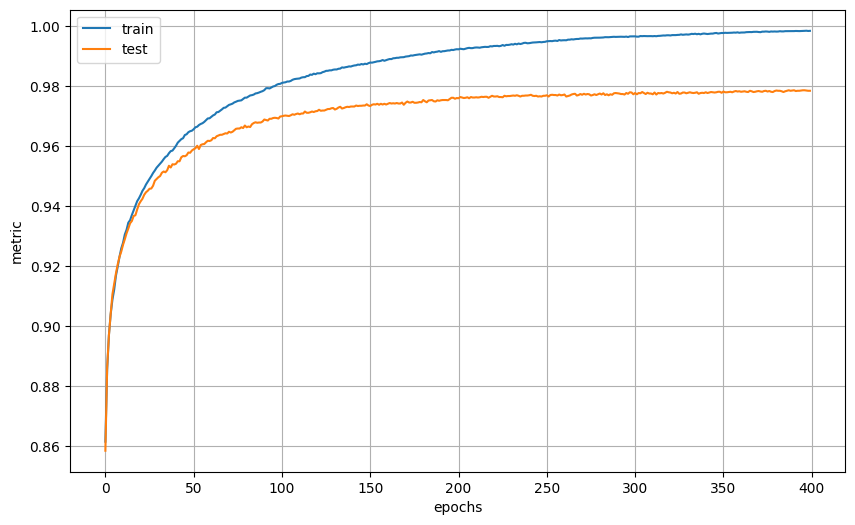

In [29]:
# mlp - multiclass (mnist)
W, b, history_train, history_test = mlp_train(X_train_mnist, X_test_mnist, y_train_mnist, y_test_mnist, [X_train_mnist.shape[0], 1024, 10], epochs=400, alpha=0.01, task_type='multiclass', batch_size=128, reg='l2');

plot_learning(history_train, history_test)

epoch 0 | Train Acc: 0.73734 | Test Acc: 0.72519
epoch 50 | Train Acc: 0.79465 | Test Acc: 0.80153
epoch 100 | Train Acc: 0.79656 | Test Acc: 0.79771
epoch 150 | Train Acc: 0.79847 | Test Acc: 0.80153
epoch 200 | Train Acc: 0.79943 | Test Acc: 0.79771
epoch 250 | Train Acc: 0.80038 | Test Acc: 0.79771
epoch 300 | Train Acc: 0.79847 | Test Acc: 0.80153
epoch 350 | Train Acc: 0.79847 | Test Acc: 0.80916
epoch 400 | Train Acc: 0.80229 | Test Acc: 0.81298
epoch 450 | Train Acc: 0.80898 | Test Acc: 0.81298
epoch 500 | Train Acc: 0.81089 | Test Acc: 0.81679
epoch 550 | Train Acc: 0.81184 | Test Acc: 0.81679
epoch 600 | Train Acc: 0.81280 | Test Acc: 0.81298
epoch 650 | Train Acc: 0.81280 | Test Acc: 0.81298
epoch 700 | Train Acc: 0.81280 | Test Acc: 0.81298
epoch 750 | Train Acc: 0.81280 | Test Acc: 0.81298
epoch 800 | Train Acc: 0.81280 | Test Acc: 0.81298
epoch 850 | Train Acc: 0.81184 | Test Acc: 0.81298
epoch 900 | Train Acc: 0.81089 | Test Acc: 0.81298
epoch 950 | Train Acc: 0.80993 | T

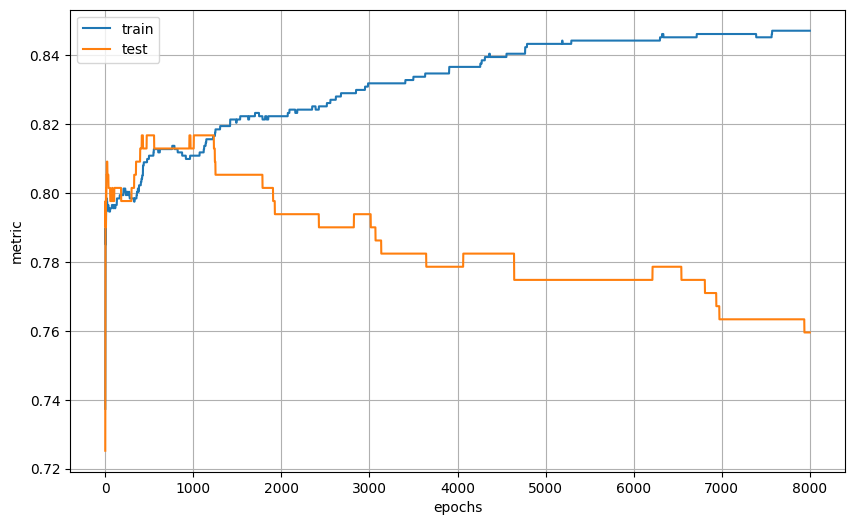

In [34]:
# mlp - binary classification (titanic)
W, b, history_train, history_test = mlp_train(X_train_titanic, X_test_titanic, y_train_titanic, y_test_titanic, [X_train_titanic.shape[0], 2048, 1], epochs=8000, alpha=0.01, task_type='binary', reg="l2");

plot_learning(history_train, history_test)

epoch 0 | Train Loss (MSE): 1.11998 | Test Loss (MSE): 1.57262
epoch 50 | Train Loss (MSE): 0.34784 | Test Loss (MSE): 0.50452
epoch 100 | Train Loss (MSE): 0.29569 | Test Loss (MSE): 0.44392
epoch 150 | Train Loss (MSE): 0.26910 | Test Loss (MSE): 0.42259
epoch 200 | Train Loss (MSE): 0.25074 | Test Loss (MSE): 0.40915
epoch 250 | Train Loss (MSE): 0.23687 | Test Loss (MSE): 0.39941
epoch 300 | Train Loss (MSE): 0.22589 | Test Loss (MSE): 0.39196
epoch 350 | Train Loss (MSE): 0.21693 | Test Loss (MSE): 0.38617
epoch 400 | Train Loss (MSE): 0.20943 | Test Loss (MSE): 0.38158
epoch 450 | Train Loss (MSE): 0.20304 | Test Loss (MSE): 0.37805
epoch 500 | Train Loss (MSE): 0.19750 | Test Loss (MSE): 0.37493
epoch 550 | Train Loss (MSE): 0.19264 | Test Loss (MSE): 0.37253
epoch 600 | Train Loss (MSE): 0.18832 | Test Loss (MSE): 0.37035
epoch 650 | Train Loss (MSE): 0.18444 | Test Loss (MSE): 0.36871
epoch 700 | Train Loss (MSE): 0.18093 | Test Loss (MSE): 0.36721
epoch 750 | Train Loss (MSE)

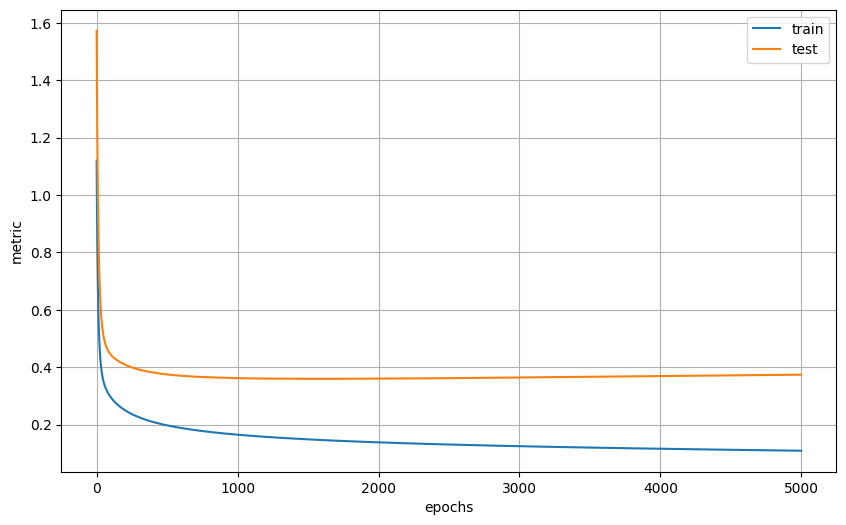

In [ ]:
# mlp - regression (housing price)
W, b, history_train, history_test = mlp_train(X_train_housing, X_test_housing, y_train_housing, y_test_housing, [X_train_housing.shape[0], 2048, 1], epochs=5000, alpha=0.000001, task_type='reg', batch_size=1);

plot_learning(history_train, history_test)

# High-level frameworks implementation

In [ ]:
# For comparison purpose, here is the same algorithm implemented, but built with high-level frameworks

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses

def mlp_train_tensorflow(X_train, y_train, layer_dims, epochs, alpha, task_type, batch_size=None):
    if X_train.shape[0] == layer_dims[0]:
        X_train = X_train.T
        y_train = y_train.T if y_train.ndim > 1 else y_train

    if batch_size is None or batch_size > len(X_train):
        batch_size = len(X_train)

    model = models.Sequential()
    model.add(layers.Input(shape=(layer_dims[0],)))
    
    for dim in layer_dims[1:-1]:
        model.add(layers.Dense(dim, activation='relu'))
        
    if task_type == 'multiclass':
        model.add(layers.Dense(layer_dims[-1]))
        loss_fn = losses.SparseCategoricalCrossentropy(from_logits=True)
        metrics = ['accuracy']
    elif task_type == 'binary':
        model.add(layers.Dense(1))
        loss_fn = losses.BinaryCrossentropy(from_logits=True)
        metrics = ['binary_accuracy']
    elif task_type == 'reg':
        model.add(layers.Dense(1))
        loss_fn = losses.MeanSquaredError()
        metrics = ['mse']

    model.compile(
        optimizer=optimizers.SGD(learning_rate=alpha),
        loss=loss_fn,
        metrics=metrics
    )

    model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )

    return model

In [ ]:
# sanity check
mlp_train_tensorflow(X_train_mnist, y_train_mnist, [784, 16, 10], epochs=100, alpha=0.5, task_type='multiclass', batch_size=128);

mlp_train_tensorflow(X_train_titanic, y_train_titanic, [X_train_titanic.shape[0], 256, 1], epochs=10000, alpha=0.01, task_type='binary');

mlp_train_tensorflow(X_train_housing, y_train_housing, [X_train_housing.shape[0], 256, 1], epochs=10000, alpha=0.001, task_type='reg', batch_size=1);

Epoch 1/100


# MLP iterative training visualization
For visualization purpose, the archtecture defined for the MNIST multiclassification problem is an input layer $a^{[0]}$ of 784 units corresponding to the 784 pixel in each 28x28 input image. A hidden layer $a^{[1]}$ will have 16 units with ReLU activation, and finally the output layer $a^{[2]}$ will have 10 units corresponding to the ten digit classes with softmax activation.

**A visualization of the learning process of a MLP trained with SGD for MNIST classification:**

In [ ]:
import pygame
import sys

def relu(Z):
    return np.maximum(Z, 0)

def relu_deriv(Z):
    return Z > 0

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def init_params():
    W1 = np.random.randn(16, 784) * np.sqrt(2.0 / 784)
    b1 = np.zeros((16, 1))
    W2 = np.random.randn(10, 16) * np.sqrt(2.0 / 16)
    b2 = np.zeros((10, 1))
    return W1, b1, W2, b2

def forward_prop(X, W1, b1, W2, b2):
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def get_loss(A2, y):
    one_hot_y = np.zeros((10, 1))
    one_hot_y[y, 0] = 1.0
    return -np.sum(one_hot_y * np.log(A2 + 1e-8)), one_hot_y

def back_prop(Z1, A1, Z2, A2, W1, W2, X, one_hot_y):
    dZ2 = A2 - one_hot_y
    dW2 = np.dot(dZ2, A1.T)
    db2 = dZ2
    
    dZ1 = np.dot(W2.T, dZ2) * relu_deriv(Z1)
    dW1 = np.dot(dZ1, X.T)
    db1 = dZ1
    
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 -= alpha * dW1
    b1 -= alpha * db1
    W2 -= alpha * dW2
    b2 -= alpha * db2
    return W1, b1, W2, b2

def array_to_surface(arr):
    arr_norm = (arr - np.min(arr)) / (np.ptp(arr) + 1e-8)
    color_array = np.stack([arr_norm * 255]*3, axis=-1).astype(np.uint8)
    surf = pygame.surfarray.make_surface(color_array.swapaxes(0, 1))
    return surf

def draw_dashed_line(surface, color, start_pos, end_pos, width=1, dash_length=10):
    x1, y1 = start_pos
    x2, y2 = end_pos
    dl = dash_length
    if x1 == x2:
        ycoords = [y for y in range(y1, y2, dl if y1 < y2 else -dl)]
        xcoords = [x1] * len(ycoords)
    elif y1 == y2:
        xcoords = [x for x in range(x1, x2, dl if x1 < x2 else -dl)]
        ycoords = [y1] * len(xcoords)
    else:
        length = ((x2 - x1)**2 + (y2 - y1)**2)**0.5
        dash_count = int(length / dl)
        xcoords = [x1 + (x2 - x1) * i / dash_count for i in range(dash_count)]
        ycoords = [y1 + (y2 - y1) * i / dash_count for i in range(dash_count)]
        
    next_coords = list(zip(xcoords[1::2], ycoords[1::2]))
    last_coords = list(zip(xcoords[0::2], ycoords[0::2]))
    for (px1, py1), (px2, py2) in zip(last_coords, next_coords):
        pygame.draw.line(surface, color, (px1, py1), (px2, py2), width)

def draw_network_graph(screen, X_val, A1_val, A2_val):
    start_x = 550
    layer_widths = [200, 200]
    center_y = 450
    node_positions = [[], [], []]
    
    l0_spacing = 25
    l0_total_nodes = 23
    l0_start_y = center_y - (l0_total_nodes - 1) * l0_spacing // 2
    input_nodes_idx = list(range(10)) + list(range(774, 784))
    
    for i, idx in enumerate(input_nodes_idx):
        if i < 10:
            pos = (start_x, l0_start_y + i * l0_spacing)
        else:
            pos = (start_x, l0_start_y + (i + 3) * l0_spacing)
        node_positions[0].append((pos, X_val[idx, 0]))
    
    for i in range(3):
        dot_y = l0_start_y + (10 + i) * l0_spacing
        pygame.draw.circle(screen, (100, 100, 100), (start_x, dot_y), 3)

    l1_spacing = 45
    l1_start_y = center_y - (16 - 1) * l1_spacing // 2
    A1_norm = (A1_val - np.min(A1_val)) / (np.ptp(A1_val) + 1e-8)
    
    for i in range(16):
        pos = (start_x + layer_widths[0], l1_start_y + i * l1_spacing)
        node_positions[1].append((pos, A1_norm[i, 0]))

    l2_spacing = 70
    l2_start_y = center_y - (10 - 1) * l2_spacing // 2
    A2_norm = (A2_val - np.min(A2_val)) / (np.ptp(A2_val) + 1e-8)
    
    for i in range(10):
        pos = (start_x + layer_widths[0] + layer_widths[1], l2_start_y + i * l2_spacing)
        node_positions[2].append((pos, A2_norm[i, 0]))

    for pos1, _ in node_positions[0]:
        for pos2, _ in node_positions[1]:
            pygame.draw.line(screen, (40, 40, 40), pos1, pos2, 1)
            
    for pos1, _ in node_positions[1]:
        for pos2, _ in node_positions[2]:
            pygame.draw.line(screen, (40, 40, 40), pos1, pos2, 1)

    for layer in node_positions:
        for pos, val in layer:
            color_val = int(val * 255)
            pygame.draw.circle(screen, (color_val, color_val, color_val), pos, 10)
            pygame.draw.circle(screen, (200, 200, 200), pos, 10, 1)

def run_visualization():
    try:
        X_train_mnist = idx2numpy.convert_from_file('data/mnist/train-images.idx3-ubyte')
        y_train_mnist = idx2numpy.convert_from_file('data/mnist/train-labels.idx1-ubyte')
    except FileNotFoundError:
        print("MNIST dataset not found.")
        sys.exit()
        
    X_train_mnist = (X_train_mnist.reshape(X_train_mnist.shape[0], -1) / 255.0).T
    total_samples = X_train_mnist.shape[1]
    
    W1, b1, W2, b2 = init_params()
    alpha = 0.05
    
    pygame.init()
    screen_width, screen_height = 1600, 900
    screen = pygame.display.set_mode((screen_width, screen_height))
    pygame.display.set_caption("SGD Training - MNIST MLP")
    clock = pygame.time.Clock()
    
    # Fonts
    font_title = pygame.font.SysFont('Arial', 32, bold=True)
    font_grid = pygame.font.SysFont('Courier New', 9, bold=True)
    font_metrics = pygame.font.SysFont('Arial', 24)
    font_small = pygame.font.SysFont('Arial', 18)
    
    accuracy_history = []
    correct_predictions = 0
    
    cell_size = 17
    grid_size = 28 * cell_size
    start_img_x = 40
    start_img_y = (screen_height - grid_size) // 2

    # Slider variables
    slider_x = 1100
    slider_y = 520
    slider_w = 400
    knob_r = 8
    min_fps = 5
    max_fps = 300
    current_fps = 300
    is_dragging = False

    for i in range(total_samples):
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                pygame.quit()
                sys.exit()
                
        # Handle Slider Input via mouse polling
        mouse_x, mouse_y = pygame.mouse.get_pos()
        mouse_click = pygame.mouse.get_pressed()
        
        knob_x = slider_x + int((current_fps - min_fps) / (max_fps - min_fps) * slider_w)
        dist = ((mouse_x - knob_x)**2 + (mouse_y - slider_y)**2)**0.5
        
        if mouse_click[0] and dist <= knob_r * 3:
            is_dragging = True
        if not mouse_click[0]:
            is_dragging = False
            
        if is_dragging:
            knob_x = max(slider_x, min(mouse_x, slider_x + slider_w))
            ratio = (knob_x - slider_x) / slider_w
            current_fps = int(min_fps + ratio * (max_fps - min_fps))
            if current_fps < 1: current_fps = 1

        # SGD Steps
        X_i = X_train_mnist[:, i:i+1]
        y_i = y_train_mnist[i]

        Z1, A1, Z2, A2 = forward_prop(X_i, W1, b1, W2, b2)
        loss, one_hot_y = get_loss(A2, y_i)
        
        prediction = np.argmax(A2)
        if prediction == y_i:
            correct_predictions += 1
        current_acc = correct_predictions / (i + 1)
        accuracy_history.append(current_acc)
        
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W1, W2, X_i, one_hot_y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)

        # Drawing
        screen.fill((10, 10, 10))

        # 0. Draw Title
        title_surf = font_title.render("MNIST MLP - SGD Training Visualization", True, (255, 255, 255))
        screen.blit(title_surf, (start_img_x, 40))

        # 1. Image Grid
        img_grid = X_i.reshape(28, 28)
        for row in range(28):
            for col in range(28):
                val = img_grid[row, col]
                color = int(val * 255)
                rect = (start_img_x + col * cell_size, start_img_y + row * cell_size, cell_size, cell_size)
                pygame.draw.rect(screen, (color, color, color), rect)
                
                if val > 0.01:
                    text_color = (0, 0, 0) if val > 0.5 else (200, 200, 200)
                    text_surf = font_grid.render(f"{val:.1f}", True, text_color)
                    text_rect = text_surf.get_rect(center=(start_img_x + col * cell_size + cell_size//2, start_img_y + row * cell_size + cell_size//2))
                    screen.blit(text_surf, text_rect)

        # 2. Network Graph
        draw_network_graph(screen, X_i, A1, A2)

        # 3. Parameters Heatmaps
        metrics_x = 1100
        
        # W1 and b1
        w1_surf = pygame.transform.scale(array_to_surface(W1), (300, 60))
        b1_surf = pygame.transform.scale(array_to_surface(b1.T), (300, 15)) # Transposed for horizontal view
        screen.blit(font_small.render("W1 Heatmap", True, (200, 200, 200)), (metrics_x, 20))
        screen.blit(w1_surf, (metrics_x, 45))
        screen.blit(font_small.render("b1 Heatmap", True, (200, 200, 200)), (metrics_x, 110))
        screen.blit(b1_surf, (metrics_x, 130))

        # W2 and b2
        w2_surf = pygame.transform.scale(array_to_surface(W2), (300, 60))
        b2_surf = pygame.transform.scale(array_to_surface(b2.T), (300, 15))
        screen.blit(font_small.render("W2 Heatmap", True, (200, 200, 200)), (metrics_x, 160))
        screen.blit(w2_surf, (metrics_x, 185))
        screen.blit(font_small.render("b2 Heatmap", True, (200, 200, 200)), (metrics_x, 250))
        screen.blit(b2_surf, (metrics_x, 270))

        # 4. Metrics Text
        iter_text = font_metrics.render(f"Iteration: {i + 1} / {total_samples}", True, (255, 200, 50))
        pred_text = font_metrics.render(f"Prediction: {prediction} | Target: {y_i}", True, (255, 255, 255))
        loss_text = font_metrics.render(f"Current Loss: {loss:.4f}", True, (255, 255, 255))
        acc_text = font_metrics.render(f"Cumulative Accuracy: {current_acc:.2%}", True, (255, 255, 255))
        
        screen.blit(iter_text, (metrics_x, 320))
        screen.blit(pred_text, (metrics_x, 360))
        screen.blit(loss_text, (metrics_x, 400))
        screen.blit(acc_text, (metrics_x, 440))

        # 5. Speed Slider UI
        screen.blit(font_small.render(f"Speed (FPS): {current_fps}", True, (255, 255, 255)), (metrics_x, 490))
        pygame.draw.line(screen, (100, 100, 100), (slider_x, slider_y), (slider_x + slider_w, slider_y), 4)
        pygame.draw.circle(screen, (255, 255, 255), (knob_x, slider_y), knob_r)

        # 6. Accuracy Graph
        graph_x, graph_y, graph_w, graph_h = metrics_x, 600, 400, 250
        pygame.draw.rect(screen, (30, 30, 30), (graph_x, graph_y, graph_w, graph_h))
        pygame.draw.line(screen, (150, 150, 150), (graph_x, graph_y + graph_h), (graph_x + graph_w, graph_y + graph_h), 2) # X Axis
        pygame.draw.line(screen, (150, 150, 150), (graph_x, graph_y), (graph_x, graph_y + graph_h), 2) # Y Axis
        
        # Target 100% line
        draw_dashed_line(screen, (255, 50, 50), (graph_x, graph_y), (graph_x + graph_w, graph_y), width=2, dash_length=8)
        
        # Legend
        screen.blit(font_small.render("Target (100%)", True, (255, 100, 100)), (graph_x + 10, graph_y + 10))
        screen.blit(font_small.render("Accuracy", True, (100, 200, 255)), (graph_x + 10, graph_y + 35))
        
        if len(accuracy_history) > 1:
            points = []
            total_points = len(accuracy_history)
            for idx, acc in enumerate(accuracy_history):
                x_pos = graph_x + (idx / max(1, total_points - 1)) * graph_w
                y_pos = graph_y + graph_h - (acc * graph_h)
                points.append((x_pos, y_pos))
            pygame.draw.lines(screen, (100, 200, 255), False, points, 2)

        pygame.display.flip()
        
        # Dynamic FPS based on slider
        clock.tick(current_fps)

if __name__ == "__main__":
    run_visualization()